# Earthquake Dataset EDA

Exploring the Indonesian earthquake catalog dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

In [2]:
# Load the dataset
df = pd.read_csv('./dataset/katalog_gempa_v2.tsv', sep='\t')
print(f"Dataset shape: {df.shape}")
print(f"\nColumns ({len(df.columns)}):")
print(df.columns.tolist())

Dataset shape: (131833, 37)

Columns (37):
['eventID', 'datetime', 'latitude', 'longitude', 'magnitude', 'mag_type', 'depth', 'phasecount', 'azimuth_gap', 'location', 'agency', 'datetimeFM', 'latFM', 'lonFM', 'magFM', 'magTypeFM', 'depthFM', 'phasecountFM', 'AzGapFM', 'scalarMoment', 'Mrr', 'Mtt', 'Mpp', 'Mrt', 'Mrp', 'Mtp', 'varianceReduction', 'doubleCouple', 'clvd', 'strikeNP1', 'dipNP1', 'rakeNP1', 'strikeNP2', 'dipNP2', 'rakeNP2', 'azgapFM', 'misfit']


C:\Users\hazel\AppData\Local\Temp\ipykernel_36472\2995429389.py:2: DtypeWarning: Columns (0: magTypeFM) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('./dataset/katalog_gempa_v2.tsv', sep='\t')


In [3]:
# Basic info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 131833 entries, 0 to 131832
Data columns (total 37 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   eventID            131833 non-null  str    
 1   datetime           131833 non-null  str    
 2   latitude           131833 non-null  float64
 3   longitude          131833 non-null  float64
 4   magnitude          131134 non-null  float64
 5   mag_type           131134 non-null  str    
 6   depth              131833 non-null  int64  
 7   phasecount         131831 non-null  float64
 8   azimuth_gap        131829 non-null  float64
 9   location           131817 non-null  str    
 10  agency             128390 non-null  str    
 11  datetimeFM         4607 non-null    str    
 12  latFM              4607 non-null    float64
 13  lonFM              4607 non-null    float64
 14  magFM              3908 non-null    float64
 15  magTypeFM          3908 non-null    str    
 16  depthFM      

In [4]:
# First few rows
df.head()

,eventID,datetime,latitude,longitude,magnitude,mag_type,depth,phasecount,azimuth_gap,location,...,doubleCouple,clvd,strikeNP1,dipNP1,rakeNP1,strikeNP2,dipNP2,rakeNP2,azgapFM,misfit
0,bmg2008vkye,2008-11-01 00:31:25.143741+00:00,-0.604440,98.895531,2.989742,MLv,20,6.0,146.70738,"Southern Sumatra, Indonesia",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,bmg2008vlag,2008-11-01 01:34:29.660856+00:00,-6.611860,129.387220,5.507549,mb,30,62.0,45.46764,Banda Sea,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,bmg2008vlaj,2008-11-01 01:38:14.802129+00:00,-3.650586,127.990680,3.539674,MLv,5,4.0,331.97404,"Seram, Indonesia",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,bmg2008vlbt,2008-11-01 02:20:05.909515+00:00,-4.198925,128.097000,2.424314,MLv,5,5.0,326.37993,Banda Sea,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,bmg2008vlcd,2008-11-01 02:32:18.756155+00:00,-4.091891,128.200470,2.410045,MLv,10,5.0,314.65474,Banda Sea,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Key statistics
df[['latitude', 'longitude', 'magnitude', 'depth']].describe()

,latitude,longitude,magnitude,depth
count,131833.000000,131833.000000,131134.000000,131833.000000
mean,-3.355926,119.278910,3.512992,49.824831
std,4.330203,10.753980,0.830535,80.013661
min,-11.231423,95.002388,0.191153,0.000000
25%,-7.829702,113.422996,2.908727,10.000000
50%,-2.841737,121.198982,3.452446,16.000000
75%,0.153950,126.840280,4.092999,54.000000
max,5.999397,140.998291,7.902198,750.000000


## Date Range

In [6]:
df['datetime'] = pd.to_datetime(df['datetime'])
print(f"Date range: {df['datetime'].min()} to {df['datetime'].max()}")
print(f"Total events: {len(df)}")

ValueError: time data "2016-08-16 16:21:22+00:00" doesn't match format "%Y-%m-%d %H:%M:%S.%f%z". You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

## Magnitude Distribution

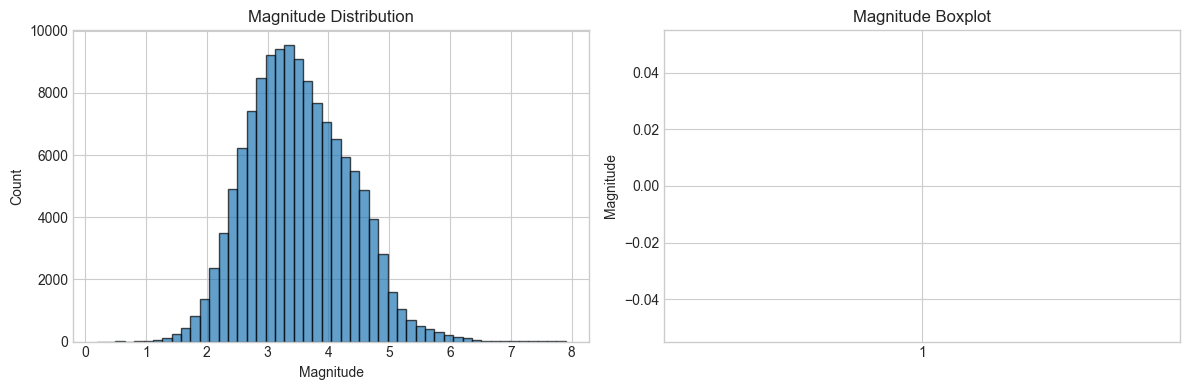


Magnitude stats:
count    131134.000000
mean          3.512992
std           0.830535
min           0.191153
25%           2.908727
50%           3.452446
75%           4.092999
max           7.902198
Name: magnitude, dtype: float64


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(df['magnitude'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Magnitude')
axes[0].set_ylabel('Count')
axes[0].set_title('Magnitude Distribution')

# Box plot
axes[1].boxplot(df['magnitude'])
axes[1].set_ylabel('Magnitude')
axes[1].set_title('Magnitude Boxplot')

plt.tight_layout()
plt.show()

print(f"\nMagnitude stats:\n{df['magnitude'].describe()}")

## Depth Distribution

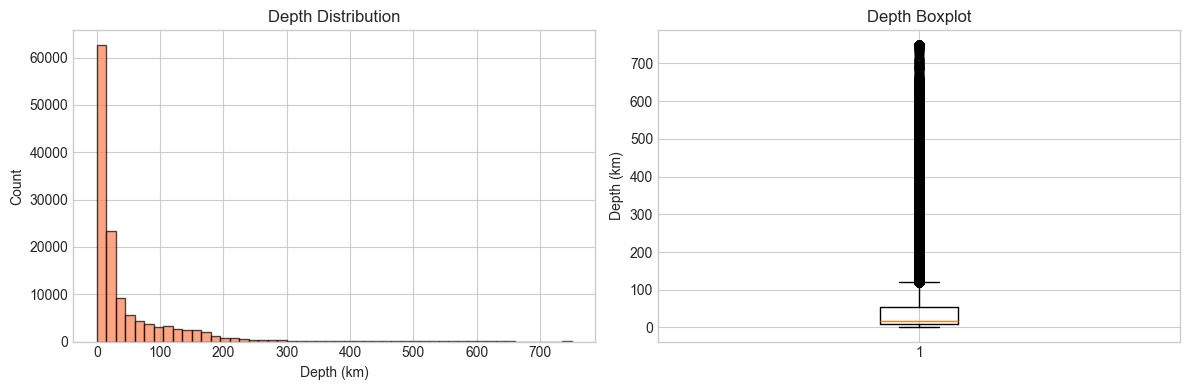


Depth stats:
count    131833.000000
mean         49.824831
std          80.013661
min           0.000000
25%          10.000000
50%          16.000000
75%          54.000000
max         750.000000
Name: depth, dtype: float64


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['depth'], bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[0].set_xlabel('Depth (km)')
axes[0].set_ylabel('Count')
axes[0].set_title('Depth Distribution')

axes[1].boxplot(df['depth'])
axes[1].set_ylabel('Depth (km)')
axes[1].set_title('Depth Boxplot')

plt.tight_layout()
plt.show()

print(f"\nDepth stats:\n{df['depth'].describe()}")

## Geographic Distribution (Lat/Lon)

In [ ]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(df['longitude'], df['latitude'], 
                      c=df['magnitude'], cmap='plasma', 
                      alpha=0.5, s=5)
plt.colorbar(scatter, label='Magnitude')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Earthquake Locations (colored by magnitude)')
plt.show()

## Events Over Time

In [ ]:
df['year'] = df['datetime'].dt.year
events_per_year = df.groupby('year').size()

plt.figure(figsize=(12, 4))
plt.bar(events_per_year.index, events_per_year.values, color='steelblue', edgecolor='black')
plt.xlabel('Year')
plt.ylabel('Number of Events')
plt.title('Earthquake Events per Year')
plt.show()

## Top Locations

In [ ]:
df['location'].value_counts().head(15)

## Magnitude by Magnitude Type

In [ ]:
plt.figure(figsize=(8, 5))
df.boxplot(column='magnitude', by='mag_type')
plt.title('Magnitude by Type')
plt.suptitle('')
plt.xlabel('Magnitude Type')
plt.ylabel('Magnitude')
plt.show()

## Magnitude vs Depth

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(df['depth'], df['magnitude'], alpha=0.3, s=10)
plt.xlabel('Depth (km)')
plt.ylabel('Magnitude')
plt.title('Magnitude vs Depth')
plt.show()

print(f"Correlation: {df['magnitude'].corr(df['depth']):.3f}")

## Missing Values

In [ ]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, 'Percent': missing_pct})
print(missing_df[missing_df['Missing'] > 0].sort_values('Missing', ascending=False))

In [ ]:
print("\n✅ EDA complete!")
print(f"Dataset summary: {len(df)} earthquakes from {df['datetime'].min().date()} to {df['datetime'].max().date()}")